In [124]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'income_tax_collection',
    persist_directory = './income_tax_collection'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [125]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

graph_builder = StateGraph(AgentState)


In [126]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

In [127]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [128]:
from langchain import hub

generate_prompt = hub.pull("rlm/rag-prompt")


def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response.content}

/home/swjeong/langchain/langgraph/.venv/lib/python3.13/site-packages/langsmith/client.py:256: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [129]:
from langchain import hub
from typing import Literal

doc_relevance_prompt = hub.pull("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal['relevant', 'irrelevant']:
    query = state['query']
    context = state['context']
    print(f'context == {context}')
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})
    print(f'doc relevance response: {response}')
    if response['Score'] == 1:
        return 'relevant'
    
    return 'irrelevant'

/home/swjeong/langchain/langgraph/.venv/lib/python3.13/site-packages/langsmith/client.py:256: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [130]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(f"""
사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요
사전: {dictionary}
질문: {{query}}
""")

def rewrite(state: AgentState):
    query = state['query']
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()

    response = rewrite_chain.invoke({'query': query})
    return {'query': response}

In [131]:
from langchain_core.prompts import PromptTemplate

from typing import Literal
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

hallucination_prompt = PromptTemplate.from_template("""
You are a teacher tasked with evaluating whether a student's answer is based on documents.
Given documents, which are excerpts from income tax law, and a student's answer;
If the student's answer is based on documents, respond with "not hallucinated",
If the student's answer is not based on documents, respond with "hallucinated".

documents: {documents}
student_answer: {student_answer}
""")

hallucination_llm = ChatOpenAI(model='gpt-4o', temperature=0)

def check_hallucination(state: AgentState) -> Literal['hallucinated', 'not hallucinated']:
    answer = state['answer']
    context = [doc.page_content for doc in state['context']]
    print(f'context == {context}')
    hallucination_chain = hallucination_prompt | hallucination_llm | StrOutputParser()
    response = hallucination_chain.invoke({'student_answer': answer, 'documents': context})
    print(f'hallucination response: {response}')
    return response

In [132]:
from langchain import hub

helpfulness_prompt = hub.pull("langchain-ai/rag-answer-helpfulness")

def check_helpfulness_grader(state: AgentState):
    query = state['query']
    answer = state['answer']
    helpfulness_chain = helpfulness_prompt | llm
    response = helpfulness_chain.invoke({'question': query, 'student_answer': answer})
    print(f'helpfulness response: {response}')
    if response['Score'] == 1:
        return 'helpful'
    return 'unhelpful'

def check_helpfulness(state: AgentState):
    return state


/home/swjeong/langchain/langgraph/.venv/lib/python3.13/site-packages/langsmith/client.py:256: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [133]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)
graph_builder.add_node('check_helpfulness', check_helpfulness)

In [ ]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
     check_doc_relevance,
     {
        'relevant':'generate',
        'irrelevant': END
    })
graph_builder.add_conditional_edges(
    'generate',
    check_hallucination,
    {
        'not hallucinated': 'check_helpfulness',
        'hallucinated': 'generate'
    }
)
graph_builder.add_conditional_edges(
    'check_helpfulness',
    check_helpfulness_grader,
    {
        'helpful': END,
        'unhelpful': 'rewrite'
    }
)
graph_builder.add_edge('rewrite','retrieve')

In [135]:
graph = graph_builder.compile()

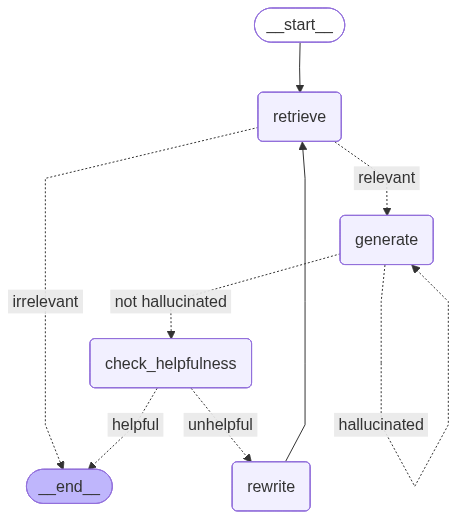

In [136]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [137]:
initial_state = {'query': '연봉 5천만원인 거주자가 납부해야 하는 소득세는 얼마인가요?'}
graph.invoke(initial_state)

context == [Document(metadata={'source': './documents/income_tax.txt'}, page_content='⑦ 제19조제12호부터 송추퍼보다, 소득세기부표와, 체육조정통과의 한법과 법 금융 소득에 대하여 제1항을 적용할 때에는 제63조를 준용한다.<개정> 2010. 12. 27.\n⑧ 비거주자가 미간접방법에 의해 경비를 인하여 제19조제1항에 따른 국내원천소득을 지급받는 경우에는 해당 범위를 바탕으로 하여 제1항에 따라 비거주자에게 실질적으로 시행하는 금액의 범위에 제19조제1에 따른 원천징수를 하여야 한다.<신설> 2010. 12. 27, 2014. 1. 1>\n⑨ 제1부 제7항까지의 규정에 따른 원천징수의무자에 대한 의무를 받는 자의 행위는 수익(收益) 또는 미입의 범미에서 본 원칙의 행위로 제8부 제9항까지의 규정을 적용한다.<신설> 2010. 12. 27.\n⑩ 제1항부터 제11항까지의 규정에 따른 원천징수를 할 때에 국내원천소득의 금액과 밖에 필요한 사항을 적은 재산경제제로서 정하는 원천징수규정은 국외원천소득을 받는 자에게 발급하여야 한다.<개정> 2010. 12. 27, 2015. 1. 1>\n⑪ 제19조제12조까지의 규정에 따른 국내원천소득으로 주식 또는 투자자가 발행한 내국법인에게 그 주식 또는 투자자본을 보유하고 있는 국외특구관리로부터 대출행위를 하여야 한다.<개정> 2010. 12. 27., 2012. 1. 1>\n⑫ 제13항에 따른 원천징수의 구체적인 방법에 관하여 대통령령으로 정한다.<개정> 2010. 12. 27.\n⑬ 제1항을 적용할 때 제19조제13항에 따른 국내원천소득이 있는 비거주자가 대출형으로 정하는 범위에 따라 각 소득에 대한 소득세를 미리 납부하였던 소득의 비과세비용은 과세비용으로 하지 않는 경우에는 그 소득에 대하여 소득세를 원천징수하지 아니한다.<개정> 2010. 12. 27, 2012. 1. 1>[전문개정 2009. 12. 31]\n소득세법\n나는 자(제119조제1호)에 따

{'query': '연봉 5천만원인 사람과 관련된 표현이 납부해야 하는 소득세는 얼마인가요?',
 'context': [Document(metadata={'source': './documents/income_tax.txt'}, page_content='⑦ 제19조제12호부터 송추퍼보다, 소득세기부표와, 체육조정통과의 한법과 법 금융 소득에 대하여 제1항을 적용할 때에는 제63조를 준용한다.<개정> 2010. 12. 27.\n⑧ 비거주자가 미간접방법에 의해 경비를 인하여 제19조제1항에 따른 국내원천소득을 지급받는 경우에는 해당 범위를 바탕으로 하여 제1항에 따라 비거주자에게 실질적으로 시행하는 금액의 범위에 제19조제1에 따른 원천징수를 하여야 한다.<신설> 2010. 12. 27, 2014. 1. 1>\n⑨ 제1부 제7항까지의 규정에 따른 원천징수의무자에 대한 의무를 받는 자의 행위는 수익(收益) 또는 미입의 범미에서 본 원칙의 행위로 제8부 제9항까지의 규정을 적용한다.<신설> 2010. 12. 27.\n⑩ 제1항부터 제11항까지의 규정에 따른 원천징수를 할 때에 국내원천소득의 금액과 밖에 필요한 사항을 적은 재산경제제로서 정하는 원천징수규정은 국외원천소득을 받는 자에게 발급하여야 한다.<개정> 2010. 12. 27, 2015. 1. 1>\n⑪ 제19조제12조까지의 규정에 따른 국내원천소득으로 주식 또는 투자자가 발행한 내국법인에게 그 주식 또는 투자자본을 보유하고 있는 국외특구관리로부터 대출행위를 하여야 한다.<개정> 2010. 12. 27., 2012. 1. 1>\n⑫ 제13항에 따른 원천징수의 구체적인 방법에 관하여 대통령령으로 정한다.<개정> 2010. 12. 27.\n⑬ 제1항을 적용할 때 제19조제13항에 따른 국내원천소득이 있는 비거주자가 대출형으로 정하는 범위에 따라 각 소득에 대한 소득세를 미리 납부하였던 소득의 비과세비용은 과세비용으로 하지 않는 경우에는 그 소득에 대하여 소득세를 원천징수하지 아니한다.<개정> 2010. 12. 27, 